In [1]:
import sys
sys.path.append("..")  # so we can import from src/

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_data

# Plot styling
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True
sns.set_style("whitegrid")

# Load data using our cached pipeline
df = load_data()
df.head()

Loading cached data from /Users/jordandonaldson/Desktop/Captsone-DS-AI/swing-trading-capstone/notebooks/../Data/raw/ohlcv.parquet


,date,ticker,open,high,low,close,volume
0,2018-01-02,AAPL,39.812824,40.313526,39.602246,40.304165,102223600
1,2018-01-03,AAPL,40.367350,40.839976,40.233987,40.297157,118071600
2,2018-01-04,AAPL,40.369681,40.587278,40.262056,40.484329,89738400
3,2018-01-05,AAPL,40.580262,41.031828,40.489013,40.945259,94640000
4,2018-01-08,AAPL,40.793171,41.087975,40.694899,40.793171,82271200


In [3]:
print(f"Total rows: {len(df):,}")
print(f"Tickers: {df['ticker'].nunique()}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"\nMissing values per column:")
print(df.isnull().sum())
print(f"\nRows per ticker:")
print(df['ticker'].value_counts())

#Universe selection avoided survivorship issues by including only stocks that traded continuously throughout the period.

Total rows: 22,110
Tickers: 11
Date range: 2018-01-02 to 2025-12-30

Missing values per column:
date      0
ticker    0
open      0
high      0
low       0
close     0
volume    0
dtype: int64

Rows per ticker:
ticker
AAPL    2010
AMZN    2010
JNJ     2010
JPM     2010
MCD     2010
META    2010
NVDA    2010
PFE     2010
SPY     2010
TSLA    2010
UNH     2010
Name: count, dtype: int64


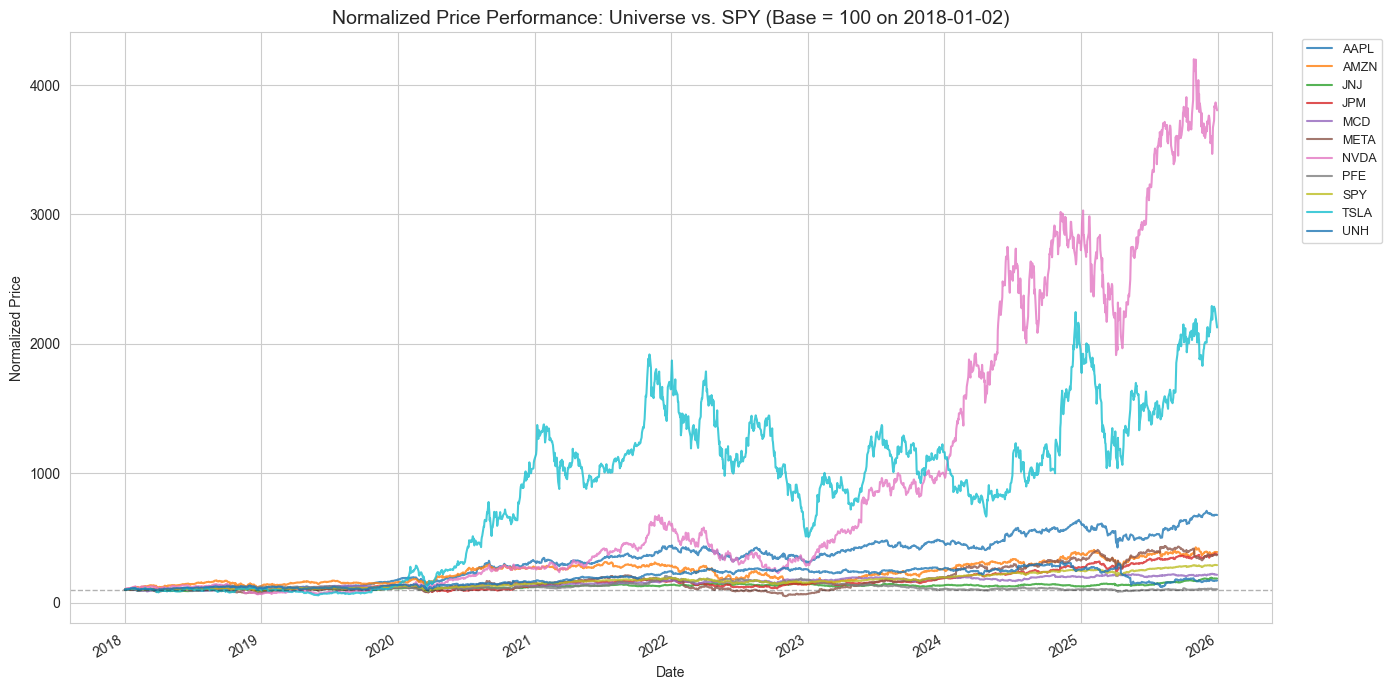

In [4]:
# Pivot to wide format: one column per ticker, rows are dates
prices_wide = df.pivot(index='date', columns='ticker', values='close')

# Normalize each series to 100 at the start, so we can compare relative performance
# (A $40 stock and a $400 stock can't be directly compared on the same axis)
prices_normalized = prices_wide / prices_wide.iloc[0] * 100

fig, ax = plt.subplots(figsize=(14, 7))
prices_normalized.plot(ax=ax, alpha=0.8)
ax.set_title('Normalized Price Performance: Universe vs. SPY (Base = 100 on 2018-01-02)', fontsize=14)
ax.set_ylabel('Normalized Price')
ax.set_xlabel('Date')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
ax.axhline(y=100, color='black', linestyle='--', alpha=0.3, linewidth=1)
plt.tight_layout()
plt.savefig('../results/01_price_performance.png', dpi=150, bbox_inches='tight')
plt.show()

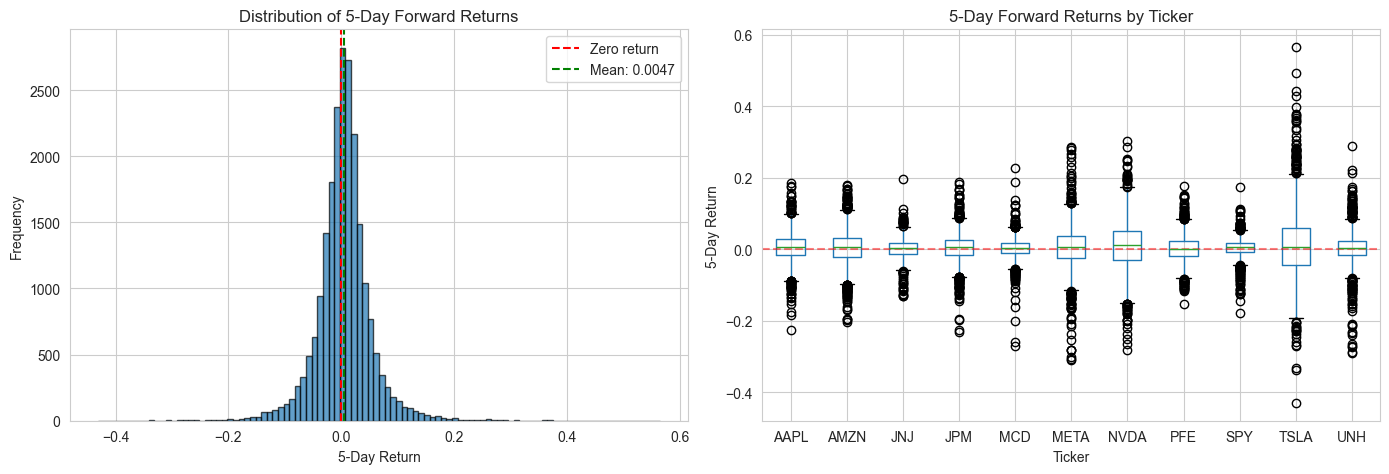

count    22055.000000
mean         0.004742
std          0.049618
min         -0.430459
25%         -0.018387
50%          0.004615
75%          0.026078
max          0.564756
Name: fwd_return_5d, dtype: float64


In [6]:
# Compute 5-day forward return for each ticker
# This is what our model will eventually predict
df = df.sort_values(['ticker', 'date'])
df['fwd_return_5d'] = df.groupby('ticker')['close'].pct_change(5).shift(-5)

# Plot the distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of all forward returns
axes[0].hist(df['fwd_return_5d'].dropna(), bins=100, edgecolor='black', alpha=0.7)
axes[0].axvline(x=0, color='red', linestyle='--', label='Zero return')
axes[0].axvline(x=df['fwd_return_5d'].mean(), color='green', linestyle='--',
                label=f"Mean: {df['fwd_return_5d'].mean():.4f}")
axes[0].set_title('Distribution of 5-Day Forward Returns')
axes[0].set_xlabel('5-Day Return')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Same data, by ticker, as boxplot
df.boxplot(column='fwd_return_5d', by='ticker', ax=axes[1])
axes[1].set_title('5-Day Forward Returns by Ticker')
axes[1].set_xlabel('Ticker')
axes[1].set_ylabel('5-Day Return')
axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
plt.suptitle('')  # remove auto-generated title
plt.tight_layout()
plt.savefig('../results/02_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary stats
print(df['fwd_return_5d'].describe())

#the conditional mean is dominated by noise; ranking is more learnable than magnitude

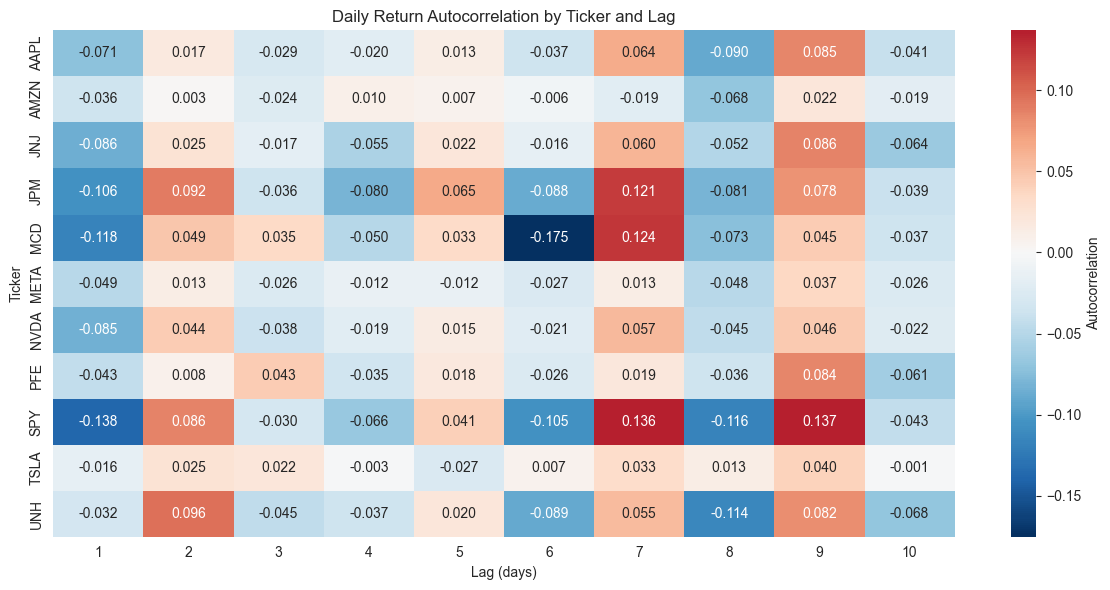

In [8]:
#Data exploration showing the key entities and their business significance
# Compute daily returns for each ticker
df['return_1d'] = df.groupby('ticker')['close'].pct_change()

# For each ticker, compute autocorrelation at lags 1-10
from scipy.stats import pearsonr

autocorr_results = []
for ticker in df['ticker'].unique():
    sub = df[df['ticker'] == ticker]['return_1d'].dropna()
    for lag in range(1, 11):
        if len(sub) > lag:
            r, p = pearsonr(sub.iloc[lag:], sub.iloc[:-lag])
            autocorr_results.append({'ticker': ticker, 'lag': lag, 'autocorr': r, 'p_value': p})

ac = pd.DataFrame(autocorr_results)
ac_pivot = ac.pivot(index='lag', columns='ticker', values='autocorr')

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(ac_pivot.T, annot=True, fmt='.3f', cmap='RdBu_r', center=0, ax=ax,
            cbar_kws={'label': 'Autocorrelation'})
ax.set_title('Daily Return Autocorrelation by Ticker and Lag')
ax.set_xlabel('Lag (days)')
ax.set_ylabel('Ticker')
plt.tight_layout()
plt.savefig('../results/03_autocorrelation.png', dpi=150, bbox_inches='tight')
plt.show()

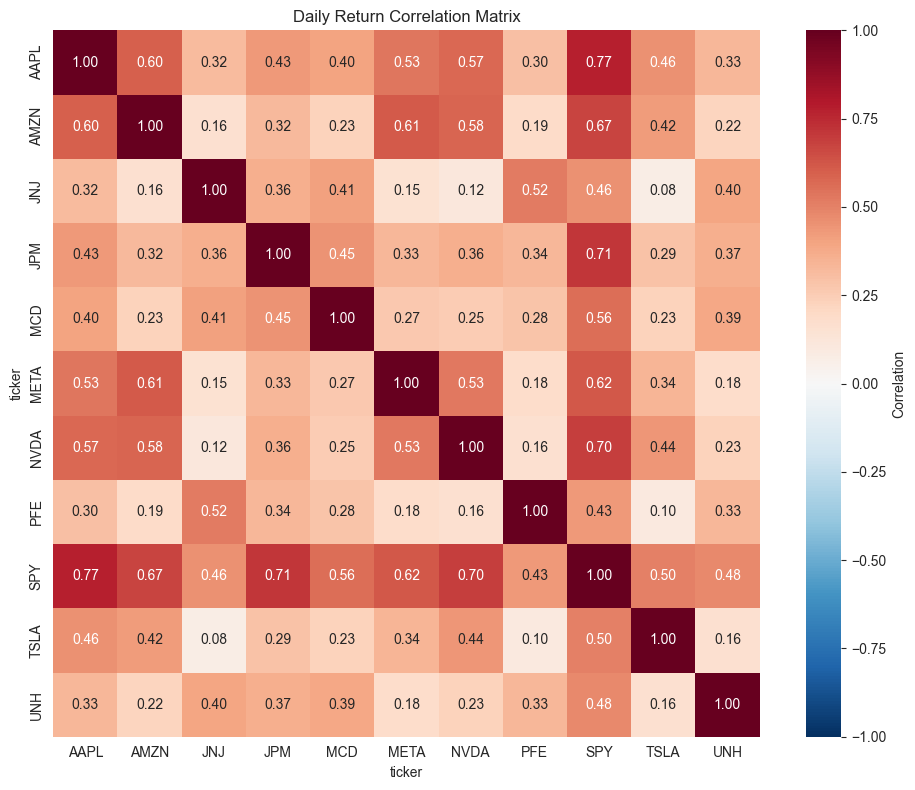

In [10]:
returns_wide = df.pivot(index='date', columns='ticker', values='return_1d')
corr_matrix = returns_wide.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, ax=ax,
            cbar_kws={'label': 'Correlation'})
ax.set_title('Daily Return Correlation Matrix')
plt.tight_layout()
plt.savefig('../results/04_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

#Stocks are positively correlated, but not perfectly. Cross-sectional dispersion exists, which is the source of alpha for our strategy.

## EDA Summary

### Data quality
- **22,110 daily observations** across 11 large-cap US tickers, 2018-01-02 to 2025-12-30
- Zero missing values; balanced panel (each ticker has 2,010 rows)
- All names traded continuously through the period — **no survivorship bias**

### Target characteristics (5-day forward returns)
- Mean: 0.47% (modest positive drift, consistent with equity premium)
- Std dev: ~5% per 5-day window
- Heavy tails: ±43% extreme observations (TSLA, NVDA driven)
- **Signal-to-noise is brutal for return magnitude prediction → motivates classification framing**

### Predictability signals
- Lag-1 daily return autocorrelation: negative for most tickers (-0.07 to -0.14)
- → Short-term mean reversion is the strongest single signal in raw price data
- SPY shows reversal at lag 6-7 (weekly momentum oscillation)
- → Justifies lagged-return features at multiple horizons

### Cross-sectional structure
- Correlations span 0.08 (TSLA-JNJ) to 0.77 (AAPL-SPY)
- Tech names cluster (AAPL, AMZN, META, NVDA: avg pairwise corr ~0.57)
- Healthcare names diversify (JNJ, PFE, UNH: lower SPY beta ~0.45)
- → Most variance is systematic; alpha must come from cross-sectional ranking

### Implications for modeling
1. **Predict relative ranking, not absolute return** — classification on top/bottom quintile
2. **Include lagged returns at multiple horizons** as features (1d, 5d, 20d, 60d)
3. **Include volatility features** — TSLA/NVDA distributions are visibly different from JNJ/PFE
4. **Include correlation-aware features** (e.g., return relative to SPY)